In [2]:
# Colab setup: clone data assets and enable interactive widgets
import os

try:
    import google.colab
    from google.colab import output
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    print("[Colab] Cloning repository assets...")
    # Clean up any leftover temporary directory before cloning
    !rm -rf _repo_tmp
    !git clone https://github.com/mattjunior039/SelfDrivingCar.git _repo_tmp
    !cp -r _repo_tmp/data . 2>/dev/null || true
    !rm -rf _repo_tmp
    
    # CRITICAL: Enable ipywidgets for the interactive tuning sliders
    output.enable_custom_widget_manager()
    
    print("[Colab] Ready and interactive widgets enabled.")

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mattjunior039/SelfDrivingCar/blob/main/phase1_heuristic_vision_and_color_spaces.ipynb)

# Phase 1 — Heuristic Vision and Color Spaces
### Self-Driving Car Curriculum · Student Workbook

---

## Why are we starting here?

Before a self-driving car can use a neural network to recognize a stop sign, it has to be able to *see* at all. And "seeing," for a computer, means working with a giant grid of numbers.

In this phase you are going to build a **stop sign detector using no machine learning whatsoever**. Just color math, filters, and geometry. This is exactly how computer vision engineers built detectors in the 1990s and 2000s, and it works surprisingly well... right up until it catastrophically doesn't.

That failure is the point. By the end of this notebook you will have built a detector that works on clean images and then watched it fall apart on shadows, sunsets, and red cars. **That frustration is the motivation for Phase 2 (learned features).** Engineers call this the *brittleness of hand-tuned heuristics*: a rule you wrote by hand only covers the situations you personally thought of.

### Learning objectives
By the end of this notebook you should be able to:
1. Explain why an image is a 3-dimensional tensor of shape `(height, width, channels)`.
2. Describe the difference between the **RGB** and **HSV** color spaces, and explain why HSV is more robust for color thresholding.
3. Explain why the color red requires **two** hue bands instead of one.
4. Use morphological operations to clean up a noisy binary mask.
5. Extract contours and filter them by **vertex count** and **area** to find octagons.
6. Identify and articulate at least three failure modes of a purely heuristic detector.

### Safety note
Everything you build here is a toy. Nothing in this notebook is safe to put in a real vehicle. Real perception stacks use redundant sensors (camera + radar + lidar), and even then a human is responsible. Keep that in mind as you see how easily this breaks.

---

## Setup

Run the cell below once. If you are on a local machine and something is missing, uncomment the `%pip install` line.

> **Note on `ipywidgets`:** the interactive slider section needs this package *and* a notebook front-end that supports widgets (VS Code, JupyterLab, or classic Notebook). If your sliders show up as raw text, you may need to restart the kernel after installing.

In [1]:
# %pip install opencv-python numpy matplotlib ipywidgets

import os
import glob

import cv2
import numpy as np
import matplotlib.pyplot as plt

import ipywidgets as widgets
from IPython.display import display

# Makes plots a readable size in the notebook.
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["image.interpolation"] = "nearest"

print("OpenCV version:", cv2.__version__)
print("NumPy version :", np.__version__)

OpenCV version: 5.0.0
NumPy version : 2.0.2


### The dataset

You are working with real frames from the **LISA Traffic Sign Dataset** — actual dashcam video captured from a moving vehicle. They are already in the workspace:

```
data/phase1_signs/
├── clean_stop_signs/              <- 15 frames, sign clearly visible and well lit
├── shadowy_occluded_stop_signs/   <- 15 frames, sign in shadow / partly hidden / odd angle
└── distractors/                   <- 15 frames with NO stop sign at all
```

### Three things to know before you start

**1. These are full road scenes, not cropped signs.** Each image is roughly **704×480** and shows an entire windscreen view — road, sky, other vehicles, buildings, foliage. The stop sign might be only 30×30 pixels off to one side. Your detector has to find it in all that clutter, which is exactly the real problem.

**2. The frames come from video, so many look similar.** Several files share a prefix like `stop_1323804359.avi_` — those are different frames from the *same* clip, seconds apart. If your detector works on one and fails on its neighbour, that is a very strong signal about how fragile your thresholds are.

**3. The `distractors` folder is the honest test.** Those frames contain brake lights, red vehicles, shop signage, and warm light — everything that *looks* like a stop sign to a colour threshold. A detector that fires on these would make a real vehicle brake for nothing.

> **Optional:** drop your own phone photos into any of these folders and they will be picked up automatically.

clean stop signs          15 images
shadowy/occluded          15 images
distractors (no sign)     15 images
File types found        : .png

Tuning image: stop_1323896946.avi_image12.png
Set STOP_SIGN_PATH to clean_paths[1], [2], ... to work on a different frame.


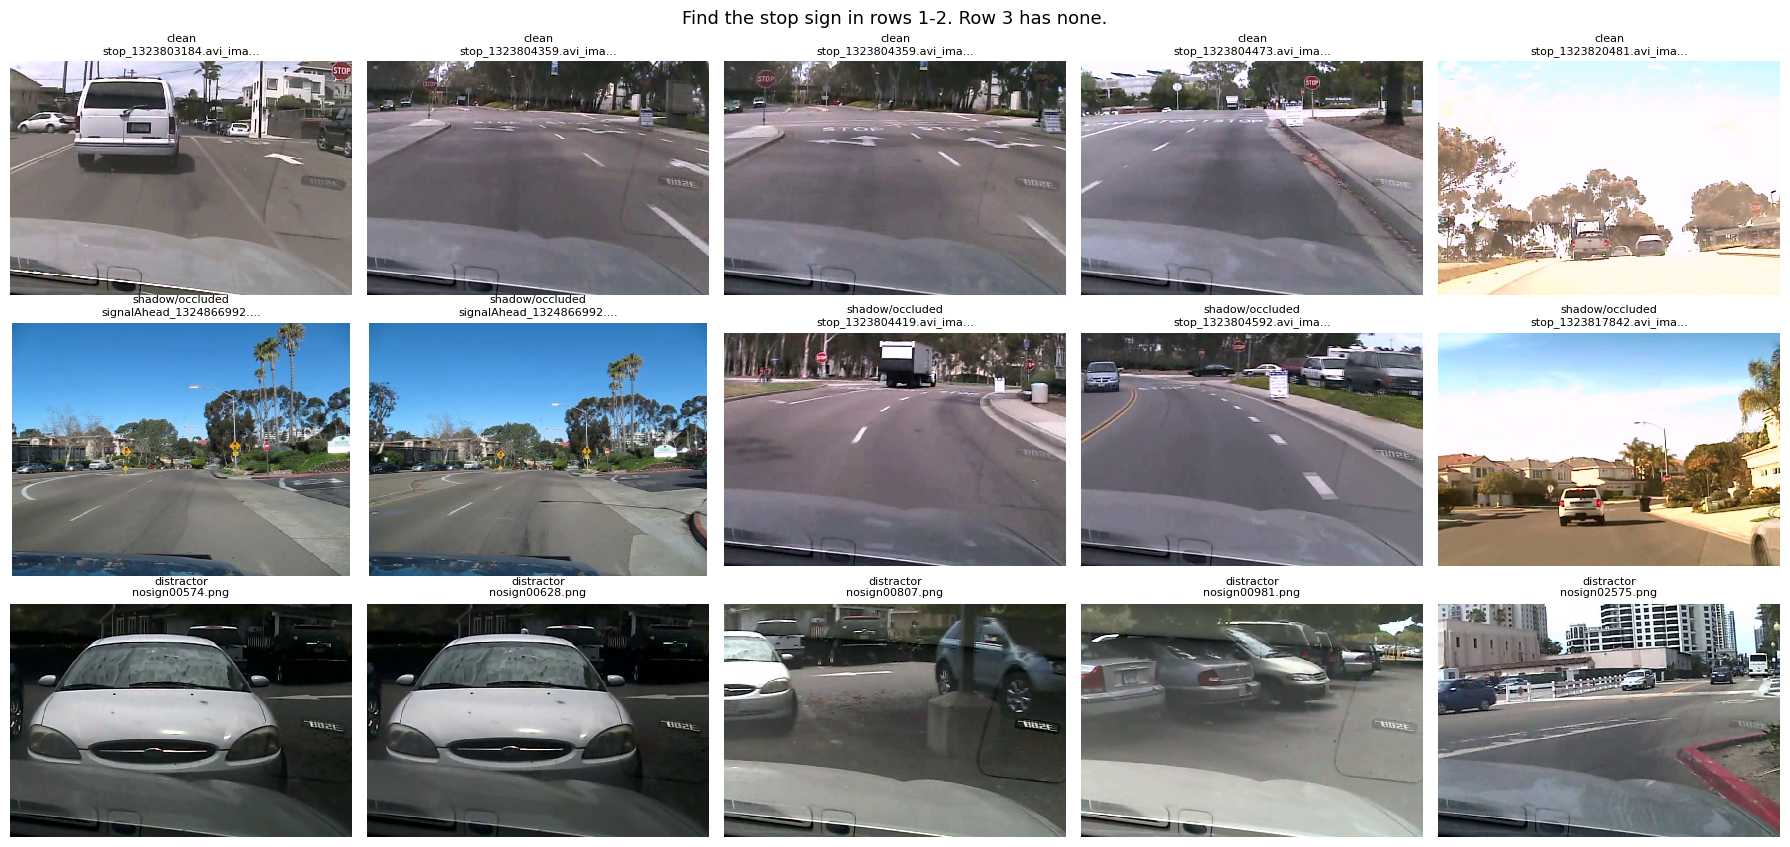

In [2]:
DATA_DIR = os.path.join("data", "phase1_signs")
CLEAN_DIR = os.path.join(DATA_DIR, "clean_stop_signs")
HARD_DIR = os.path.join(DATA_DIR, "shadowy_occluded_stop_signs")
DISTRACTOR_DIR = os.path.join(DATA_DIR, "distractors")

IMAGE_EXTS = ("*.png", "*.jpg", "*.jpeg", "*.bmp")


def list_images(folder):
    return sorted(p for ext in IMAGE_EXTS for p in glob.glob(os.path.join(folder, ext)))


def load_rgb(path, max_width=None):
    """Load an image from disk and return it in RGB order, optionally downscaled."""
    bgr = cv2.imread(path, cv2.IMREAD_COLOR)
    if bgr is None:
        raise FileNotFoundError(
            f"Could not read '{path}'. Check the path and that the file is a real image."
        )
    # Signs are already small in these frames, so we do NOT downscale by default.
    if max_width is not None and bgr.shape[1] > max_width:
        scale = max_width / bgr.shape[1]
        bgr = cv2.resize(bgr, None, fx=scale, fy=scale, interpolation=cv2.INTER_AREA)
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)


def short_name(path, width=26):
    """LISA filenames are long; trim them for plot titles."""
    name = os.path.basename(path)
    return name if len(name) <= width else name[: width - 3] + "..."


clean_paths = list_images(CLEAN_DIR)
hard_paths = list_images(HARD_DIR)
distractor_paths = list_images(DISTRACTOR_DIR)

if not clean_paths:
    raise FileNotFoundError(
        f"No images found in '{CLEAN_DIR}'. Check that the data/phase1_signs folder "
        "sits next to this notebook."
    )

# The well-lit frame we tune against in Sections 1-3: the one where the sign is largest.
# Matched on the filename STEM so it survives a .png -> .jpg re-export.
PREFERRED_STEM = "stop_1323896946.avi_image12"


def stem(path):
    return os.path.splitext(os.path.basename(path))[0]


STOP_SIGN_PATH = next((p for p in clean_paths if stem(p) == PREFERRED_STEM), None)
if STOP_SIGN_PATH is None:
    STOP_SIGN_PATH = clean_paths[0]
    print(f"NOTE: '{PREFERRED_STEM}' not found, falling back to {os.path.basename(STOP_SIGN_PATH)}.")
    print("The sign may be small in this frame; try other entries in clean_paths.")

for label, paths in [("clean stop signs", clean_paths),
                     ("shadowy/occluded", hard_paths),
                     ("distractors (no sign)", distractor_paths)]:
    print(f"{label:<24} {len(paths):>3} images")

exts = sorted({os.path.splitext(p)[1] for p in clean_paths + hard_paths + distractor_paths})
print(f"File types found        : {', '.join(exts)}")

print(f"\nTuning image: {os.path.basename(STOP_SIGN_PATH)}")
print("Set STOP_SIGN_PATH to clean_paths[1], [2], ... to work on a different frame.")

# Contact sheet: see what you are up against before writing any detection code.
N_PREVIEW = 5
_rows = [("clean", clean_paths), ("shadow/occluded", hard_paths), ("distractor", distractor_paths)]

fig, axes = plt.subplots(len(_rows), N_PREVIEW, figsize=(3.6 * N_PREVIEW, 2.9 * len(_rows)))
for _r, (_label, _paths) in enumerate(_rows):
    for _c in range(N_PREVIEW):
        ax = axes[_r, _c]
        ax.axis("off")
        if _c < len(_paths):
            ax.imshow(load_rgb(_paths[_c]))
            ax.set_title(f"{_label}\n{short_name(_paths[_c])}", fontsize=8)

plt.suptitle("Find the stop sign in rows 1-2. Row 3 has none.", fontsize=13)
plt.tight_layout()
plt.show()

---
# 1. Pixels as Multi-Channel Tensors

## The mental model

A color image is **not** a picture. To the computer it is a 3-dimensional array — a *tensor* — of shape:

$$\text{image} \in \mathbb{Z}^{H \times W \times C}, \qquad 0 \le \text{pixel} \le 255$$

- $H$ = height in pixels (number of rows)
- $W$ = width in pixels (number of columns)
- $C$ = channels, which is 3 for a color image

Each channel is its own full-size grayscale image. Stack the Red sheet, the Green sheet, and the Blue sheet, and your eye blends them back into color.

```
        ┌─────────────┐
       ┌┤  BLUE  (2)  │
      ┌┤├─────────────┤   each sheet is H × W
      │││  GREEN (1)  │   values 0–255 (uint8)
      │├┼─────────────┤
      ││  RED   (0)   │
      └┴──────────────┘
```

## The BGR gotcha

**OpenCV loads images as BGR, not RGB.** This is a historical accident from the 1990s camera hardware OpenCV was originally written for, and it has confused every single person who has ever used the library.

If you ever see a photo where the sky is orange and people's skin is blue, you forgot to convert. Always convert immediately after loading:

```python
rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
```

## What to expect in the channel plots

When you split a stop sign into channels, look carefully:
- The **Red** channel will be *bright* where the sign face is (high red value) and bright on the white letters too.
- The **Green** and **Blue** channels will be *dark* on the sign face but still bright on the white letters.

Why? Because white is $(255, 255, 255)$ — it is maxed out in *every* channel. Red is roughly $(200, 30, 30)$. This is your first hint that "just look at the red channel" is not a sufficient detector.

### Exercise 1.1 — Load and inspect

Load the clean stop sign, convert it to RGB, and print its shape and dtype.

In [3]:
# Load the raw image in OpenCV's native BGR order.
stop_bgr = cv2.imread(STOP_SIGN_PATH, cv2.IMREAD_COLOR)

if stop_bgr is None:
    raise FileNotFoundError(
        f"Could not read '{STOP_SIGN_PATH}'. Run the path-setup cell above first."
    )

# Choose a conversion and see how the channel ordering affects the result.
conversion_dropdown = widgets.Dropdown(
    options={
        "Correct: cv2.COLOR_BGR2RGB": cv2.COLOR_BGR2RGB,
        "Wrong: cv2.COLOR_RGB2BGR": cv2.COLOR_RGB2BGR,
        "Wrong: cv2.COLOR_BGR2GRAY": cv2.COLOR_BGR2GRAY,
        "Wrong: cv2.COLOR_BGR2HSV": cv2.COLOR_BGR2HSV,
    },
    value=cv2.COLOR_BGR2RGB,
    description="Conversion:",
)
display(conversion_dropdown)

# Change the dropdown and re-run this cell to compare the results in Exercise 1.2.
stop_rgb = cv2.cvtColor(stop_bgr, conversion_dropdown.value)

assert stop_rgb is not None, "Choose a conversion and run the cell again."
print("Selected conversion:", conversion_dropdown.label)
print("Shape (H, W, C):", stop_rgb.shape)
print("Data type      :", stop_rgb.dtype)
print("Min / Max value:", stop_rgb.min(), "/", stop_rgb.max())
print("Total numbers  :", stop_rgb.size, "  <- this is how many values the computer stores")

Dropdown(description='Conversion:', options={'Correct: cv2.COLOR_BGR2RGB': 4, 'Wrong: cv2.COLOR_RGB2BGR': 4, '…

Selected conversion: Correct: cv2.COLOR_BGR2RGB
Shape (H, W, C): (480, 640, 3)
Data type      : uint8
Min / Max value: 0 / 255
Total numbers  : 921600   <- this is how many values the computer stores


### Exercise 1.2 — See the BGR bug with your own eyes

Plot the *unconverted* BGR array next to the correct RGB array. Matplotlib always assumes RGB, so the left image will look wrong on purpose.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

axes[0].imshow(stop_bgr)  # deliberately wrong
axes[0].set_title("BGR array shown as if it were RGB\n(the bug)")

axes[1].imshow(stop_rgb)
axes[1].set_title("Correctly converted to RGB")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

### Exercise 1.3 — Split the channels

Slice out each channel and display it as a grayscale heatmap.

**Indexing reminder:** `image[:, :, 0]` means "every row, every column, channel 0." For an RGB image, channel 0 = Red, 1 = Green, 2 = Blue.

We plot with `cmap="gray"` and pin the scale with `vmin=0, vmax=255` so all three panels are directly comparable. If you let matplotlib auto-scale, a dark channel gets stretched to look bright and you will misread it.

In [ ]:
# ------------------------------------------------------------------
# YOUR CODE HERE
# Extract the three channels from `stop_rgb` using NumPy slicing.
# Each should be a 2-D array of shape (H, W).
# ------------------------------------------------------------------
red_channel = None    # <-- replace
green_channel = None  # <-- replace
blue_channel = None   # <-- replace


channels = {"Red": red_channel, "Green": green_channel, "Blue": blue_channel}
assert all(c is not None for c in channels.values()), "Fill in all three channels first."

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(stop_rgb)
axes[0].set_title("Original (RGB)")
axes[0].axis("off")

for ax, (name, chan) in zip(axes[1:], channels.items()):
    im = ax.imshow(chan, cmap="gray", vmin=0, vmax=255)
    ax.set_title(f"{name} channel\nmean = {chan.mean():.1f}")
    ax.axis("off")
    fig.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout()
plt.show()

### Exercise 1.4 — Probe a single pixel

The stop sign is tiny in this full road frame, so do not try to guess coordinates from the whole image. Run the cell below first: it automatically crops in tight around the sign and plots it with a labelled coordinate grid drawn in the *original* image's row/col numbers.

Read the row (y-axis) and col (x-axis) directly off the gridlines to find a point on the red face and a point on a white letter. Enter those `(row, col)` pairs in the next cell — its green crosshairs and zoomed crops confirm you picked what you meant to.

> **Coordinate reminder:** image arrays use `stop_rgb[row, col]`, so `row` is the y-axis and `col` is the x-axis. The image origin is at the top-left.

> If the automatic crop misses the sign (rare, but possible on an unusual frame), edit the `row0, row1, col0, col1` fallback values printed in the cell's `else` branch and re-run.

In [ ]:
# Automatically crop in tight around the stop sign, then plot it with a coordinate
# grid labelled in the ORIGINAL image's row/col numbers (not crop-local numbers).
#
# This red-blob heuristic exists ONLY to find a zoom box for this exercise -- it is
# not the detector you will build in Section 3. A full road scene can contain other
# red objects (cars, trucks, brake lights), so we don't just bound ALL red pixels --
# that would merge the sign with anything else red in the frame. Instead we look at
# each separate red-ish blob and keep the one that is roughly sign-sized and
# roughly square, which a stop sign is and a red truck or car usually is not.
red_ch = stop_rgb[:, :, 0].astype(int)
green_ch = stop_rgb[:, :, 1].astype(int)
blue_ch = stop_rgb[:, :, 2].astype(int)
red_like = ((red_ch > 100) & (red_ch - green_ch > 40) & (red_ch - blue_ch > 40)).astype(np.uint8)

MIN_BLOB_AREA, MAX_BLOB_AREA = 60, 1000  # a road-scene stop sign, in pixels
MIN_ASPECT, MAX_ASPECT = 0.5, 2.0        # roughly square, not a long red car/truck

n_blobs, _, blob_stats, _ = cv2.connectedComponentsWithStats(red_like, connectivity=8)

best_blob = None
for i in range(1, n_blobs):  # start at 1: label 0 is the background
    x, y, w, h, area = blob_stats[i]
    if not (MIN_BLOB_AREA <= area <= MAX_BLOB_AREA):
        continue
    aspect = w / h if h else 0
    if not (MIN_ASPECT <= aspect <= MAX_ASPECT):
        continue
    if best_blob is None or area > best_blob[4]:
        best_blob = (x, y, w, h, area)

pad = 25
if best_blob is not None:
    x, y, w, h, _ = best_blob
    row0, row1 = max(y - pad, 0), min(y + h + pad, stop_rgb.shape[0])
    col0, col1 = max(x - pad, 0), min(x + w + pad, stop_rgb.shape[1])
else:
    # Auto-detection found no sign-shaped red blob -- edit this box by hand and re-run.
    row0, row1 = 150, 300
    col0, col1 = 300, 450
    print("NOTE: automatic detection failed on this frame; using a placeholder box.")
    print("Edit row0, row1, col0, col1 above to frame the sign yourself, then re-run.")

crop = stop_rgb[row0:row1, col0:col1]

tick_step = 10
fig, ax = plt.subplots(figsize=(9, 9))
# `extent` keeps the tick labels in ORIGINAL image coordinates, not crop-local ones.
ax.imshow(crop, extent=(col0, col1, row1, row0))
ax.set_title("Zoomed view of the stop sign region")
ax.set_xlabel("col / x")
ax.set_ylabel("row / y")
ax.set_xticks(np.arange(col0, col1 + 1, tick_step))
ax.set_yticks(np.arange(row0, row1 + 1, tick_step))
ax.grid(color="white", alpha=0.5, linewidth=0.8)
plt.tight_layout()
plt.show()

print(f"Crop shown: rows {row0}-{row1}, cols {col0}-{col1}")
print("Read the row (y-axis) and col (x-axis) directly off the gridlines above.")

In [ ]:
# ------------------------------------------------------------------
# YOUR CODE HERE
# Choose (row, col) coordinates for a red pixel and a white pixel.
# ------------------------------------------------------------------
red_pixel_rc = (0, 0)    # <-- replace with a point on the red face
white_pixel_rc = (0, 0)  # <-- replace with a point on a white letter


for label, (r, c) in [("Red face ", red_pixel_rc), ("White text", white_pixel_rc)]:
    r_val, g_val, b_val = stop_rgb[r, c]
    print(f"{label} at (row={r}, col={c}) -> R={r_val:3d}  G={g_val:3d}  B={b_val:3d}")

# Zoomed crops so you can confirm you hit what you meant to hit.
fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))
for ax, (label, (r, c)) in zip(axes, [("red pixel", red_pixel_rc), ("white pixel", white_pixel_rc)]):
    pad = 25
    r0, r1 = max(0, r - pad), min(stop_rgb.shape[0], r + pad)
    c0, c1 = max(0, c - pad), min(stop_rgb.shape[1], c + pad)
    ax.imshow(stop_rgb[r0:r1, c0:c1])
    ax.plot(c - c0, r - r0, "+", color="lime", markersize=16, markeredgewidth=2)
    ax.set_title(f"{label} at (row={r}, col={c})", fontsize=10)
    ax.axis("off")
plt.tight_layout()
plt.show()

---
# 2. RGB vs. HSV Color Spaces

## The problem with RGB

Reflection 1 should have exposed the core issue: in RGB, **brightness and color are tangled together**. Darkening a red pixel changes all three numbers at once. So a rule that works at noon breaks at dusk, and a rule tuned for a sunny sign fails on the shaded half of that same sign.

What we actually want is to ask *"what color is this?"* separately from *"how bright is it?"*

## Enter HSV

HSV rearranges the exact same information into three more human-meaningful axes:

| Channel | Name | Meaning | OpenCV range |
|---|---|---|---|
| H | **Hue** | *Which* color — position on the color wheel | `0–179` |
| S | **Saturation** | *How pure* — 0 is gray, 255 is vivid | `0–255` |
| V | **Value** | *How bright* — 0 is black, 255 is fully lit | `0–255` |

> ### ⚠️ The `0–179` trap
> Hue is naturally measured in degrees around a circle, $0°$ to $360°$. But OpenCV stores images as `uint8`, which maxes out at 255. So OpenCV **halves** the hue: it stores $0$–$179$ instead of $0$–$359$.
>
> This means every hue value you look up online must be divided by 2. Pure red is $0°$ → `0`. Cyan is $180°$ → `90`. If you copy a hue of `240` from a web color picker into OpenCV, it will silently wrap or clip and your mask will be empty. This is the single most common bug in this notebook.

## Why red needs TWO bands

Hue is a **circle**, but a NumPy array is a **line**. Red sits exactly at the seam where the circle is cut open:

```
    OpenCV hue axis (what the array sees):

    0 ──── 30 ──── 60 ──── 90 ──── 120 ──── 150 ──── 179
   RED   orange  yellow   cyan    blue    magenta   RED
    ↑                                                ↑
    └────────── these are the SAME color ────────────┘
```

Red wraps around the ends. A single `cv2.inRange(hsv, low, high)` call can only select a *contiguous* slice, so it can grab the low-red band **or** the high-red band, never both. The solution is to build two masks and combine them:

```python
mask_low  = cv2.inRange(hsv, (0,   s_min, v_min), (h1,  s_max, v_max))
mask_high = cv2.inRange(hsv, (h2,  s_min, v_min), (179, s_max, v_max))
mask = cv2.bitwise_or(mask_low, mask_high)
```

Blue or green would need only one band. Red is uniquely annoying — which is unfortunate, because traffic engineering chose red for the single most safety-critical sign on the road.

### Exercise 2.1 — Visualize the HSV channels

Before tuning anything, build intuition. Convert the stop sign to HSV and look at each channel.

Watch the **Saturation** channel especially closely: the red sign face should be near-white (highly saturated) while the gray pole, asphalt, and overcast sky should be near-black. Saturation is often a stronger discriminator than hue itself.

In [ ]:
# ------------------------------------------------------------------
# YOUR CODE HERE
# Convert `stop_rgb` into HSV. Careful: the source is RGB, not BGR,
# so you need the COLOR_RGB2HSV flag (not COLOR_BGR2HSV).
# ------------------------------------------------------------------
stop_hsv = None  # <-- replace


assert stop_hsv is not None, "Convert to HSV first."

titles = ["Hue (0-179)", "Saturation (0-255)", "Value (0-255)"]
maxima = [179, 255, 255]
cmaps = ["hsv", "gray", "gray"]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(stop_rgb)
axes[0].set_title("Original")
axes[0].axis("off")

for i, ax in enumerate(axes[1:]):
    im = ax.imshow(stop_hsv[:, :, i], cmap=cmaps[i], vmin=0, vmax=maxima[i])
    ax.set_title(titles[i])
    ax.axis("off")
    fig.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout()
plt.show()

### Exercise 2.2 — The interactive threshold tuner

This is the heart of Phase 1. The sliders below let you hunt for the dual-band red boundaries by hand.

**How to use it:**
1. Start by dragging **`s_min`** up until the gray road, sky, and concrete go black. Saturation does most of the heavy lifting.
2. Then raise **`v_min`** to kill deep shadows and black regions (where hue is meaningless noise).
3. Now tune **`h_low_max`** — the top of the *low* red band. Typical useful values are around 8–12.
4. Finally tune **`h_high_min`** — the bottom of the *high* red band. Typical useful values are around 160–172.
5. Toggle `show_bands` to see the two masks separately in orange and cyan. This makes the wrap-around concrete.

**Your goal:** the sign face solid white, everything else black. It will not be perfect. Get it as close as you can and write your numbers down.

> **A concrete target:** a stop sign occupies a *tiny* fraction of a 704×480 road frame. When your mask is well tuned, the "% of pixels kept" readout should be well under **1%**. If it reads 15%, you are still selecting sky, brick, and tail lights — keep raising `s_min`.

> **Debugging:** if the mask is entirely black, your `s_min` or `v_min` is too high. If it is entirely white, they are too low. If your sliders render as plain text, `ipywidgets` is not enabled in your front-end.

In [ ]:
def build_red_mask(hsv, h_low_max, h_high_min, s_min, s_max, v_min, v_max):
    """Return a binary mask (0 or 255) selecting red pixels across BOTH hue bands."""
    # ------------------------------------------------------------------
    # YOUR CODE HERE
    # 1. lower_band: hue from 0 up to h_low_max
    # 2. upper_band: hue from h_high_min up to 179
    # 3. Combine them with cv2.bitwise_or
    #
    # The bound arrays must be np.uint8 and ordered (H, S, V).
    # Example of one band:
    #     lo = np.array([0, s_min, v_min], dtype=np.uint8)
    #     hi = np.array([h_low_max, s_max, v_max], dtype=np.uint8)
    #     lower_band = cv2.inRange(hsv, lo, hi)
    # ------------------------------------------------------------------
    lower_band = np.zeros(hsv.shape[:2], dtype=np.uint8)  # <-- replace
    upper_band = np.zeros(hsv.shape[:2], dtype=np.uint8)  # <-- replace
    combined = np.zeros(hsv.shape[:2], dtype=np.uint8)    # <-- replace

    return combined, lower_band, upper_band

In [ ]:
# Self-Check Unit Test: Mask Properties
def test_mask_structure():
    dummy_hsv = np.zeros((100, 100, 3), dtype=np.uint8)
    # Put a red pixel in lower band (H=5, S=200, V=200) and upper band (H=175, S=200, V=200)
    dummy_hsv[10, 10] = [5, 200, 200]
    dummy_hsv[20, 20] = [175, 200, 200]
    
    comb, lo, hi = build_red_mask(dummy_hsv, 10, 170, 100, 255, 60, 255)
    
    assert comb.dtype == np.uint8, "Mask must be uint8."
    assert comb.shape == (100, 100), "Mask must be 2D of shape (H, W)."
    assert comb[10, 10] == 255, "Low-hue band pixel must be included in combined mask."
    assert comb[20, 20] == 255, "High-hue band pixel must be included in combined mask."
    assert set(np.unique(comb)).issubset({0, 255}), "Mask values must be strictly 0 or 255."
    print("[PASS] Dual-band HSV mask logic validated successfully!")

test_mask_structure()

In [ ]:
# --- Choose which image the tuner operates on -------------------------------
# Swap in any of these to re-tune on a harder frame:
#     clean_paths[0] ... clean_paths[-1]
#     hard_paths[0]  ... hard_paths[-1]        (shadow / occlusion)
#     distractor_paths[0] ...                  (no sign at all)
TUNER_IMAGE_PATH = STOP_SIGN_PATH

tuner_rgb = load_rgb(TUNER_IMAGE_PATH)
tuner_hsv = cv2.cvtColor(tuner_rgb, cv2.COLOR_RGB2HSV)
print("Tuning on:", os.path.basename(TUNER_IMAGE_PATH))


def preview_threshold(h_low_max, h_high_min, s_min, s_max, v_min, v_max, show_bands):
    mask, lower_band, upper_band = build_red_mask(
        tuner_hsv, h_low_max, h_high_min, s_min, s_max, v_min, v_max
    )

    isolated = cv2.bitwise_and(tuner_rgb, tuner_rgb, mask=mask)

    if show_bands:
        band_view = np.zeros_like(tuner_rgb)
        band_view[lower_band > 0] = (255, 140, 0)   # orange = low-hue band
        band_view[upper_band > 0] = (0, 200, 255)   # cyan   = high-hue band
        third, third_title = band_view, "Low band (orange) vs High band (cyan)"
    else:
        third, third_title = isolated, "Original masked by mask"

    coverage = 100.0 * (mask > 0).mean()

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
    axes[0].imshow(tuner_rgb)
    axes[0].set_title("Input")
    axes[1].imshow(mask, cmap="gray", vmin=0, vmax=255)
    axes[1].set_title(f"Combined mask — {coverage:.2f}% of pixels kept")
    axes[2].imshow(third)
    axes[2].set_title(third_title)
    for ax in axes:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

    print(
        "Current settings -> "
        f"h_low_max={h_low_max}, h_high_min={h_high_min}, "
        f"s=({s_min},{s_max}), v=({v_min},{v_max})"
    )


controls = widgets.interactive(
    preview_threshold,
    h_low_max=widgets.IntSlider(value=10, min=0, max=90, step=1, description="h_low_max"),
    h_high_min=widgets.IntSlider(value=170, min=90, max=179, step=1, description="h_high_min"),
    s_min=widgets.IntSlider(value=100, min=0, max=255, step=1, description="s_min"),
    s_max=widgets.IntSlider(value=255, min=0, max=255, step=1, description="s_max"),
    v_min=widgets.IntSlider(value=60, min=0, max=255, step=1, description="v_min"),
    v_max=widgets.IntSlider(value=255, min=0, max=255, step=1, description="v_max"),
    show_bands=widgets.Checkbox(value=False, description="show the two bands"),
)
display(controls)

### Exercise 2.3 — Lock in your parameters

Copy the numbers the tuner printed into the dictionary below. Everything downstream in this notebook reads from `RED_PARAMS`, so this is your detector's "configuration file."

Then re-run the tuner on **two or three frames from `hard_paths` and `distractor_paths`** (change `TUNER_IMAGE_PATH` and re-run both cells). Do the same numbers still work? Keep notes — you will need them for Section 4.

In [ ]:
# ------------------------------------------------------------------
# YOUR CODE HERE — paste your tuned values.
# ------------------------------------------------------------------
RED_PARAMS = {
    "h_low_max": 10,
    "h_high_min": 170,
    "s_min": 100,
    "s_max": 255,
    "v_min": 60,
    "v_max": 255,
}


def red_mask(rgb, params=None):
    """Convenience wrapper: RGB image in, binary red mask out."""
    params = RED_PARAMS if params is None else params
    hsv = cv2.cvtColor(rgb, cv2.COLOR_RGB2HSV)
    mask, _, _ = build_red_mask(hsv, **params)
    return mask


_check = red_mask(stop_rgb)
print(f"Sanity check: mask keeps {100.0 * (_check > 0).mean():.2f}% of pixels.")
print("If that number is 0.00, go back and finish build_red_mask().")

> ### ✍️ Reflection 2
> 1. Which single slider made the biggest difference in removing background clutter? Why do you think that is?
> 2. Explain the hue wrap-around to someone who has never seen a color wheel. Use an analogy (a clock face is a good start).
> 3. You tuned these six numbers by eye, on one photo. How many photos would you need to check before you'd trust these numbers on a real road? Is that a realistic amount of work?

*Your answers:*

1. 
2. 
3. 

---
# 3. Morphological Cleaning & Contour Extraction

## Your mask is messy

Look closely at the mask from Section 2. You will see two kinds of defects:

- **Salt noise:** scattered lone white pixels out in the background — a reddish leaf, a brick, JPEG compression artifacts.
- **Pepper holes:** black gaps *inside* the sign, caused by the white lettering, glare, and dirt.

Both will wreck contour detection. Noise creates hundreds of tiny fake shapes; holes can split one sign into several fragments.

## Morphological operations

Morphology slides a small shape (the **kernel** or *structuring element*) across the mask and applies a local rule.

| Operation | Rule | Effect | Use it to |
|---|---|---|---|
| **Erosion** | keep white only if *all* neighbors are white | shrinks white regions | delete tiny specks |
| **Dilation** | make white if *any* neighbor is white | grows white regions | fill small gaps |
| **Opening** | erode → dilate | removes specks, keeps big blobs the same size | clean the background |
| **Closing** | dilate → erode | fills holes, keeps outer boundary the same size | seal the letters |

The magic of opening and closing is that they are **size-preserving**: erosion alone would shrink your sign, but following it with dilation restores the original size while the specks — already destroyed — never come back.

**Order matters.** Open first (kill the noise), then close (fill the holes). If you close first you will inflate the noise specks into blobs too big for opening to remove.

## From mask to shape: contours

`cv2.findContours` traces the boundary of every connected white region and returns each one as an array of $(x, y)$ points. A stop sign's contour might have 300+ points because of pixel-level jaggedness.

`cv2.approxPolyDP` then simplifies that using the **Ramer–Douglas–Peucker** algorithm: it repeatedly discards points that lie close to a straight line between their neighbors. "Close" is controlled by `epsilon`, which we set as a fraction of the perimeter so it scales with the object:

$$\epsilon = k \cdot \text{arcLength}(\text{contour})$$

- **$k$ too small** (e.g. `0.005`) → barely simplifies, you get 40 vertices, no octagon detected.
- **$k$ too large** (e.g. `0.10`) → oversimplifies, your octagon collapses into a square.
- **$k \approx 0.02$–$0.04$** is the usual sweet spot for an octagon.

## The detection rule

A stop sign is a **regular octagon**. So we filter for:
1. `len(approx) == 8` — eight vertices.
2. `cv2.contourArea(...) > MIN_AREA` — big enough to be real, not a speck.
3. *(optional, recommended)* aspect ratio near 1.0 — an octagon's bounding box is roughly square, which rejects long thin red things like car bumpers and awnings.

### Exercise 3.1 — Clean the mask

Instead of typing the `cv2.morphologyEx` calls yourself, drag the `KERNEL_SIZE` slider below and watch the salt-and-pepper noise disappear (or the sign start eroding away) in real time. Small kernels barely touch the noise; large kernels can eat the sign's corners. `KERNEL_SIZE` stays set to whatever the slider shows when you move on — later cells reuse it.

In [ ]:
KERNEL_SIZE = 3  # updated live by the slider below

def make_kernel(size):
    return cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (size, size))

kernel = make_kernel(KERNEL_SIZE)

def clean_mask(mask, k=None):
    """Remove speckle noise (open), then fill interior holes (close)."""
    if k is None:
        k = kernel
    opened = cv2.morphologyEx(mask, cv2.MORPH_OPEN, k)
    closed = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, k)
    return closed

raw = red_mask(stop_rgb)
cleaned = clean_mask(raw)  # overwritten by the slider callback below

def preview_morphology(size):
    global KERNEL_SIZE, kernel, cleaned
    KERNEL_SIZE = size
    kernel = make_kernel(size)
    cleaned = clean_mask(raw, kernel)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
    axes[0].imshow(raw, cmap="gray", vmin=0, vmax=255)
    axes[0].set_title("Raw mask")
    axes[1].imshow(cleaned, cmap="gray", vmin=0, vmax=255)
    axes[1].set_title(f"After open+close (k={size})")
    axes[2].imshow(cv2.absdiff(raw, cleaned), cmap="magma", vmin=0, vmax=255)
    axes[2].set_title("Pixels that changed")
    for ax in axes:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

    coverage = 100.0 * (cleaned > 0).mean()
    print(f"KERNEL_SIZE={size}  ->  {coverage:.2f}% of pixels kept after cleaning")

widgets.interact(
    preview_morphology,
    size=widgets.IntSlider(value=3, min=1, max=15, step=2, description="KERNEL_SIZE")
)


### Exercise 3.2 — Inspect every contour before you filter

Run this diagnostic **before** writing your filter. It prints the vertex count and area of every candidate so you can pick a sensible `MIN_AREA` from real data rather than guessing.

In [ ]:
EPSILON_FACTOR = 0.03

contours, _ = cv2.findContours(cleaned, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
print(f"findContours returned {len(contours)} regions.\n")

rows = []
for c in contours:
    area = cv2.contourArea(c)
    perim = cv2.arcLength(c, True)
    approx = cv2.approxPolyDP(c, EPSILON_FACTOR * perim, True)
    x, y, w, h = cv2.boundingRect(approx)
    rows.append((len(approx), area, w / h if h else 0))

rows.sort(key=lambda r: -r[1])
print(f"{'vertices':>9} {'area':>12} {'aspect w/h':>12}")
print("-" * 35)
for v, a, ar in rows[:20]:
    print(f"{v:>9} {a:>12.1f} {ar:>12.2f}")

print("\nThe sign should be one of the largest entries. Note its area — that guides MIN_AREA.")
print("On these 704x480 frames a stop sign is often only 25-60 px across, so expect an")
print("area in the low hundreds, NOT thousands. Set MIN_AREA below what you see here.")

### Exercise 3.3 — Write the octagon filter

This is the core logic of your detector. Fill in the `if` statement.

> ### ⚠️ Set your expectations first
> Start with the strict rule: **exactly 8 vertices**. Run it. On these frames it will fire on roughly **1 or 2 of the 15 clean images**, and you have not done anything wrong.
>
> Here is why. A stop sign 35 pixels wide has corners only 4–5 pixels long. After thresholding and morphology, those corners are mangled, so `approxPolyDP` returns 7 vertices, or 9, or 6 — almost anything but a clean 8. The octagon is a fact about the *sign*; it is not a reliable fact about the *pixels*.
>
> Once you have seen that happen, come back and relax the rule to a **range** (`6 <= len(approx) <= 10`). Recall improves noticeably. Then check what it did to the distractor folder in Section 4 — you will find you bought those extra detections with false positives.
>
> **Even a well-tuned version of this detector finds the sign in only about a third of the clean frames.** That is the honest performance ceiling of colour-and-shape heuristics on real dashcam video, and it is the entire argument for Phase 2.

In [ ]:
MIN_AREA = 80           # tune from your Exercise 3.2 table
TARGET_VERTICES = 8     # a stop sign is an octagon
ASPECT_TOLERANCE = 0.35 # how far from square the bounding box may be


def find_stop_signs(rgb, params=None, epsilon_factor=EPSILON_FACTOR):
    """Full heuristic pipeline: RGB -> HSV threshold -> clean -> contours -> filter.

    Returns a list of dicts, one per accepted detection.
    """
    mask = clean_mask(red_mask(rgb, params))
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    detections = []
    for contour in contours:
        perimeter = cv2.arcLength(contour, True)
        if perimeter == 0:
            continue

        approx = cv2.approxPolyDP(contour, epsilon_factor * perimeter, True)
        area = cv2.contourArea(approx)
        x, y, w, h = cv2.boundingRect(approx)
        aspect_ratio = w / float(h) if h > 0 else 0.0

        # ==============================================================
        # YOUR CODE HERE
        #
        # Write ONE if-statement that accepts this contour only when:
        #   (a) it has exactly TARGET_VERTICES vertices  -> len(approx)
        #   (b) its area is greater than MIN_AREA        -> area
        #   (c) its bounding box is roughly square       -> aspect_ratio
        #       i.e. abs(aspect_ratio - 1.0) < ASPECT_TOLERANCE
        #
        # If it passes, append the detection dict below.
        # Start with just (a) and (b); add (c) once that works and see
        # how many false positives it removes.
        #
        # SECOND PASS: once you have seen how rarely exactly-8 fires,
        # relax (a) to a range, e.g. 6 <= len(approx) <= 10, and compare.
        #
        # if ...:
        #     detections.append({
        #         "approx": approx,
        #         "bbox": (x, y, w, h),
        #         "area": area,
        #         "vertices": len(approx),
        #     })
        # ==============================================================
        pass

    return detections


def draw_detections(rgb, detections):
    """Return a copy of `rgb` with each detection outlined and labelled."""
    out = rgb.copy()
    for d in detections:
        cv2.drawContours(out, [d["approx"]], -1, (0, 255, 0), 3)
        x, y, _, _ = d["bbox"]
        cv2.putText(
            out,
            f"STOP? v={d['vertices']} a={int(d['area'])}",
            (x, max(y - 8, 12)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (0, 255, 0),
            2,
        )
    return out

In [ ]:
dets = find_stop_signs(stop_rgb)
print(f"Detections on the clean image: {len(dets)}")
for d in dets:
    print("   ", {k: v for k, v in d.items() if k != "approx"})

plt.figure(figsize=(9, 7))
plt.imshow(draw_detections(stop_rgb, dets))
plt.title("Heuristic detector — clean image")
plt.axis("off")
plt.show()

# Now the honest question: how many of the 15 clean frames does it find?
hits = sum(len(find_stop_signs(load_rgb(p))) > 0 for p in clean_paths)
print(f"\nFound a sign in {hits} of {len(clean_paths)} CLEAN frames "
      f"({100 * hits / len(clean_paths):.0f}% recall).")
print("These are the easy images. Section 4 uses the hard ones.")

In [ ]:
# Self-Check Unit Test: Detector Output Schema
def test_detector_schema():
    dummy_rgb = np.zeros((200, 200, 3), dtype=np.uint8)
    # Draw a simple red square
    cv2.rectangle(dummy_rgb, (50, 50), (120, 120), (220, 20, 20), -1)
    
    dets = find_stop_signs(dummy_rgb)
    assert isinstance(dets, list), "find_stop_signs must return a list."
    if len(dets) > 0:
        required_keys = {"approx", "bbox", "area", "vertices"}
        assert required_keys.issubset(dets[0].keys()), f"Each detection dict must contain: {required_keys}"
        assert len(dets[0]["bbox"]) == 4, "'bbox' must be a tuple/list of (x, y, w, h)."
    print("[PASS] Detector output format verified!")

test_detector_schema()

### Exercise 3.4 — Sensitivity sweep

Drag the `epsilon_factor` slider below and watch the green polygon redraw live on the stop sign. At low values the outline hugs every jagged pixel (too many vertices); at high values the octagon visibly collapses into a square or triangle. This is the Ramer–Douglas–Peucker algorithm working in front of your eyes — no math required.

Fill in the table in the markdown cell after this one with what you observe.

In [ ]:
def preview_epsilon(epsilon_factor):
    contours, _ = cv2.findContours(cleaned, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    overlay = stop_rgb.copy()
    rows = []

    for c in contours:
        perimeter = cv2.arcLength(c, True)
        if perimeter == 0:
            continue
        approx = cv2.approxPolyDP(c, epsilon_factor * perimeter, True)
        area = cv2.contourArea(approx)
        if area < 20:  # skip specks too small to matter
            continue
        cv2.drawContours(overlay, [approx], -1, (0, 255, 0), 2)
        for point in approx.reshape(-1, 2):
            cv2.circle(overlay, tuple(point), 4, (255, 255, 0), -1)
        rows.append((len(approx), area))

    rows.sort(key=lambda r: -r[1])

    plt.figure(figsize=(8, 7))
    plt.imshow(overlay)
    plt.title(f"epsilon_factor={epsilon_factor:.3f}  (green = simplified polygon, dots = vertices)")
    plt.axis("off")
    plt.show()

    print(f"{'vertices':>9} {'area':>10}")
    print("-" * 21)
    for v, a in rows[:8]:
        print(f"{v:>9} {a:>10.1f}")

widgets.interact(
    preview_epsilon,
    epsilon_factor=widgets.FloatSlider(
        value=0.03, min=0.005, max=0.10, step=0.005,
        readout_format=".3f", description="epsilon_factor"
    )
)


*Record your observations:*

| Parameter changed | Value tried | Detections | What went wrong |
|---|---|---|---|
| `epsilon_factor` | 0.005 | | |
| `epsilon_factor` | 0.10 | | |
| `MIN_AREA` | 20 | | |
| `KERNEL_SIZE` | 15 | | |
| `s_min` | 40 | | |

---
# 4. The Edge-Case Breakdown

## The moment of truth

Your detector works on the photo you tuned it on. That is not impressive — you *fitted the parameters to that photo*. The real question is whether it generalizes.

The cell below runs your pipeline across every frame in `shadowy_occluded_stop_signs/` and `distractors/` and lays the results out in a grid. Expect carnage.

## Vocabulary you will need

- **False positive:** the detector says STOP but there is no sign (a red car, a brake light, a Coca-Cola billboard). In a real vehicle this causes **phantom braking** — the car slams on the brakes on a highway. This is genuinely dangerous and has caused real crashes.
- **False negative:** there *is* a sign and the detector misses it (shadow, rain, faded paint, a sticker). The car sails through an intersection.

Neither is acceptable, and notice the grim trade-off: every slider you loosen to catch more shadowed signs also lets in more red cars.

## Failure modes to look for

| Failure | Root cause | Which stage broke |
|---|---|---|
| Shadow across the sign | V drops below `v_min`; sign splits in two | HSV threshold |
| Overcast / washed-out light | saturation drops below `s_min` | HSV threshold |
| Brake lights or a red vehicle | colour is genuinely red; only shape can save you | shape filter |
| Sign at a sharp angle | perspective makes the octagon non-square; `approxPolyDP` returns 5–7 vertices | contour filter |
| Sign far down the road | area falls below `MIN_AREA` | area filter |
| Partly occluded by a pole or branch | contour is broken; vertex count is wrong | contour filter |
| Motion blur from the moving vehicle | edges smear, so the polygon loses vertices | contour filter |

As you review the grid, your job is to name **which stage** of the pipeline broke for each image. That diagnostic skill is more valuable than the detector itself.

In [ ]:
# The gauntlet: hard positives (sign present) + distractors (no sign present).
adversarial_paths = hard_paths + distractor_paths

if not adversarial_paths:
    raise FileNotFoundError(
        f"No images found under '{HARD_DIR}' or '{DISTRACTOR_DIR}'."
    )

print(f"{len(hard_paths)} shadowy/occluded frames  (a stop sign IS present)")
print(f"{len(distractor_paths)} distractor frames        (NO stop sign present)")
print(f"{len(adversarial_paths)} total\n")

for p in adversarial_paths:
    print("  -", os.path.basename(p))

### Exercise 4.1 — Label the ground truth

The computer cannot grade itself. Here the folder a frame came from gives us the label for free: everything in `shadowy_occluded_stop_signs/` contains a sign, everything in `distractors/` does not.

> This is not busywork. **Label noise is one of the most common reasons a perception system reports numbers better than reality.** If your ground truth is wrong, every metric downstream is wrong too — and it will look like the detector is failing when in fact it is right.

> ### ⚠️ Do not trust labels you have not checked>
> Two files in the hard folder are named `signalAhead_*`, because the original dataset annotated them for a *different* sign type. Open them. If a stop sign is not actually visible, add the filename to `LABEL_OVERRIDES` below with `False`.

In [ ]:
# Folder membership gives the default label. Keys are filename STEMS, so the
# labels keep working if the dataset is ever re-exported in another format.
GROUND_TRUTH = {stem(p): True for p in hard_paths}
GROUND_TRUTH.update({stem(p): False for p in distractor_paths})

# ------------------------------------------------------------------
# YOUR CODE HERE
# Open the frames and correct any label that is wrong.
# Start with the two signalAhead_* files - is a stop sign really visible?
# Use the filename WITHOUT its extension.
# ------------------------------------------------------------------
LABEL_OVERRIDES = {
    # "signalAhead_1324866992.avi_image6": False,
    # "signalAhead_1324866992.avi_image10": False,
}

unknown = set(LABEL_OVERRIDES) - set(GROUND_TRUTH)
if unknown:
    raise KeyError(f"These override keys match no image: {sorted(unknown)}")

GROUND_TRUTH.update(LABEL_OVERRIDES)


def has_sign(path):
    return GROUND_TRUTH[stem(path)]


n_pos = sum(GROUND_TRUTH.values())
print(f"{n_pos} frames labelled 'stop sign present'")
print(f"{len(GROUND_TRUTH) - n_pos} frames labelled 'no stop sign'")
if LABEL_OVERRIDES:
    print(f"({len(LABEL_OVERRIDES)} label(s) corrected by hand)")

### Exercise 4.2 — Run the gauntlet

Green border = the detector got it right. Red border = it was wrong.

Set `SHOW_MASKS = True` to also render each image's cleaned mask underneath. That second row is where you diagnose *why* a failure happened: a black mask means the threshold stage failed; a full-looking mask with no box means the shape stage failed.

In [ ]:
SHOW_MASKS = True
N_COLS = 5

results = []
for path in adversarial_paths:
    rgb = load_rgb(path)
    detections = find_stop_signs(rgb)
    truth = has_sign(path)
    predicted = len(detections) > 0

    if predicted and truth:
        outcome = "TRUE POSITIVE"
    elif predicted and not truth:
        outcome = "FALSE POSITIVE"
    elif not predicted and truth:
        outcome = "FALSE NEGATIVE"
    else:
        outcome = "TRUE NEGATIVE"

    results.append(
        {
            "name": short_name(path),
            "rgb": rgb,
            "mask": clean_mask(red_mask(rgb)),
            "overlay": draw_detections(rgb, detections),
            "n": len(detections),
            "outcome": outcome,
            "correct": predicted == truth,
        }
    )

rows_per_image = 2 if SHOW_MASKS else 1
n_rows = rows_per_image * int(np.ceil(len(results) / N_COLS))

fig, axes = plt.subplots(n_rows, N_COLS, figsize=(5 * N_COLS, 4.2 * n_rows))
axes = np.atleast_2d(axes)

for i, r in enumerate(results):
    block, col = divmod(i, N_COLS)
    top = axes[block * rows_per_image, col]

    edge = "limegreen" if r["correct"] else "red"
    top.imshow(r["overlay"])
    top.set_title(f"{r['name']}\n{r['outcome']} · {r['n']} detection(s)", fontsize=10)
    top.set_xticks([])
    top.set_yticks([])
    for spine in top.spines.values():
        spine.set_edgecolor(edge)
        spine.set_linewidth(4)

    if SHOW_MASKS:
        bottom = axes[block * rows_per_image + 1, col]
        bottom.imshow(r["mask"], cmap="gray", vmin=0, vmax=255)
        bottom.set_title(
            f"cleaned mask — {100.0 * (r['mask'] > 0).mean():.1f}% kept", fontsize=9
        )
        bottom.axis("off")

# Hide any unused panels.
for j in range(len(results), n_rows // rows_per_image * N_COLS):
    block, col = divmod(j, N_COLS)
    for k in range(rows_per_image):
        axes[block * rows_per_image + k, col].axis("off")

plt.tight_layout()
plt.show()

### Exercise 4.3 — Score the damage

In [ ]:
tp = sum(r["outcome"] == "TRUE POSITIVE" for r in results)
fp = sum(r["outcome"] == "FALSE POSITIVE" for r in results)
fn = sum(r["outcome"] == "FALSE NEGATIVE" for r in results)
tn = sum(r["outcome"] == "TRUE NEGATIVE" for r in results)

print("           Confusion matrix")
print("                  predicted sign   predicted none")
print(f"  actual sign  {tp:>12}   {fn:>15}")
print(f"  actual none  {fp:>12}   {tn:>15}")

precision = tp / (tp + fp) if (tp + fp) else float("nan")
recall = tp / (tp + fn) if (tp + fn) else float("nan")
accuracy = (tp + tn) / len(results)

print(f"\n  Precision (of the alarms, how many were real?) : {precision:.2f}")
print(f"  Recall    (of the real signs, how many caught?): {recall:.2f}")
print(f"  Accuracy                                       : {accuracy:.2f}")

print("\nFailures:")
for r in results:
    if not r["correct"]:
        print(f"  {r['outcome']:<16} {r['name']}")

### Exercise 4.4 — Try to fix it (and discover you can't)

Pick your worst false negative. Go back to the tuner in Section 2, load that image, and find parameters that *do* catch it. Paste them below and re-run the whole adversarial set with them.

**Prediction:** you will fix that one image and break two others. Prove yourself right or wrong.

In [ ]:
# ------------------------------------------------------------------
# YOUR CODE HERE — parameters re-tuned to rescue your worst failure.
# ------------------------------------------------------------------
RESCUE_PARAMS = dict(RED_PARAMS)  # start from your originals, then edit
# RESCUE_PARAMS["v_min"] = ...
# RESCUE_PARAMS["s_min"] = ...


print(f"{'image':<30} {'original':>10} {'rescued':>10}")
print("-" * 52)
changed = 0
for r in results:
    rescued = len(find_stop_signs(r["rgb"], params=RESCUE_PARAMS))
    flag = "  <-- changed" if rescued != r["n"] else ""
    changed += rescued != r["n"]
    print(f"{r['name']:<30} {r['n']:>10} {rescued:>10}{flag}")

print(f"\n{changed} image(s) changed behaviour. How many got better vs. worse?")

---
## ✍️ Final Reflection — Write-up

Answer these in full sentences. This is the assessed portion of Phase 1.

**1. Failure taxonomy.** Pick three failures from your grid. For each, state the filename, whether it was a false positive or false negative, and **which pipeline stage** broke (HSV threshold / morphology / contour approximation / area-and-shape filter). Justify using the mask image.

**2. The trade-off.** Describe concretely what happened in Exercise 4.4. Which direction did you move your parameters, what did it rescue, and what did it break? Explain why this trade-off is structural rather than something you could fix with more patience.

**3. Cost of errors.** A false positive causes phantom braking; a false negative means running a stop sign. Argue which is worse *for a car on a highway* and which is worse *for a car in a school zone*. Does one setting of the sliders work for both situations?

**4. Counting the knobs.** List every hand-chosen number in your pipeline (there are at least ten: six HSV bounds, kernel size, epsilon factor, min area, aspect tolerance, target vertices). If each one had just 10 plausible settings, how many combinations exist? Could you test them all by hand?

**5. The bridge to Phase 2.** A neural network learns its own filters from labelled examples rather than having you type numbers. Given what you just experienced, name one clear advantage of that approach — and one new problem it introduces that heuristics do not have. (Think about what you'd need to *collect* before you could train anything, and about whether you could still explain *why* the model fired.)

*Your write-up:*

**1.**

**2.**

**3.**

**4.**

**5.**

---
## Stretch goals (optional)

- **Normalize the lighting.** Apply CLAHE (`cv2.createCLAHE`) to the V channel before thresholding. Does it rescue your shadow image?
- **Add a white-pixel check.** A real stop sign has white lettering inside the red boundary. Crop each detection's bounding box and require that 10–35% of it be high-V, low-S pixels. How many red cars does this reject?
- **Sweep the whole grid.** Write a loop over several `s_min` and `v_min` values, compute accuracy for each, and plot a heatmap. Where is the best cell, and how good is "best"?
- **Video.** Point `cv2.VideoCapture` at a dashcam clip and run the detector frame by frame. Watch detections flicker on and off — real systems add temporal smoothing to cope.
- **Try another sign.** Yield signs are red-and-white triangles. How much of your code has to change to detect `len(approx) == 3`? What does that tell you about how well heuristics scale to 50 sign classes?

---

### ➡️ Next: Phase 2 — Learned Features
You will replace every hand-tuned number in this notebook with weights learned from data — and discover a whole new set of failure modes.